# **Reproductive Health factors Analaysis**

Stage 1 – Problem Definition and Dataset Selection

📌 Business Problem

Healthcare providers often lack clear insights into how different health factors such as blood pressure, glucose levels, BMI, and age contribute to pregnancy risks.

This makes it difficult to:

Identify high-risk pregnancies early
Provide timely medical intervention
Reduce complications for both mother and baby

**Key Objectives:**


*   Identify high-risk vs low-risk pregnancies
*   Detect critical health indicators affecting pregnancy
*   Analyze patterns and correlations between features
*   Build a predictive model for risk classification
*   Provide visual insights/dashboard for monitoring















**Dataset Selection & Description**

**Dataset Name:** Pregnancy Health / Maternal Risk Dataset

**Number of Rows:** (depends on your dataset, e.g., ~1000+)

**Number of Columns:** (e.g., 6–15 features typically)

✔ Suitable For:

    Exploratory Data Analysis (EDA)
    Data Visualization
    Machine Learning (Classification)
    Healthcare Insights

The dataset contains both numerical and categorical features, such as:

Age → Mother’s age

SystolicBP → Upper blood pressure

DiastolicBP → Lower blood pressure

BS (Blood Sugar) → Glucose level

BodyTemp → Body temperature

HeartRate → Pulse rate

RiskLevel → Target variable (Low / Mid / High risk)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/email2ssuganya/Reproductive-Health/main/Public_Health_Birth_Data__Pregnancy_Health_and_Risk_Factors.csv"

df = pd.read_csv(url)
df.head()

,Year,Place,Age Group,Race and Ethnicity,Count of Alcohol Consumption,Rate of Alcohol Consumption,Count of Diabetes,Rate of Diabetes,Count of Hypertension,Rate of Hypertension,Count of Smoking,Rate of Smoking,Count of Low Weight Gain,Rate of Low Weight Gain,Count of Inadequate Prenatal Care,Rate of Inadequate Prenatal Care,Count of Other Risks,Rate of Other Risks
0,2015,Aggregated Region: Suburban Cook County,10 to 14,All Race/Eth,0,0,0,0,0,0,0,0,*,*,8,*,0,0
1,2015,Aggregated Region: Suburban Cook County,15 to 17,All Race/Eth,0,0,6,*,19,*,11,*,149,42.9,190,54.8,30,8.6
2,2015,Aggregated Region: Suburban Cook County,45 to 54,All Race/Eth,0,0,16,*,23,22.5,0,0,44,43.1,28,27.5,40,39.2
3,2015,Aggregated Region: Suburban Cook County,55+,All Race/Eth,0,0,0,0,0,0,*,*,0,0,*,*,0,0
4,2015,Aggregated Region: Suburban Cook County,10 to 14,Hispanic,0,0,0,0,0,0,0,0,*,*,*,*,0,0


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())

# Missing values
print(df.isnull().sum())

(35226, 18)
Index(['Year', 'Place', 'Age Group', 'Race and Ethnicity',
       'Count of Alcohol Consumption', 'Rate of Alcohol Consumption',
       'Count of Diabetes', 'Rate of Diabetes', 'Count of Hypertension',
       'Rate of Hypertension', 'Count of Smoking', 'Rate of Smoking',
       'Count of Low Weight Gain', 'Rate of Low Weight Gain',
       'Count of Inadequate Prenatal Care', 'Rate of Inadequate Prenatal Care',
       'Count of Other Risks', 'Rate of Other Risks'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35226 entries, 0 to 35225
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Year                               35226 non-null  int64 
 1   Place                              35226 non-null  object
 2   Age Group                          35226 non-null  object
 3   Race and Ethnicity                 35226 non-null  object
 4   Count

In [ ]:
df.replace("*", np.nan, inplace=True)

# Drop missing values (simple approach)
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

In [ ]:
# Missing values
print(df.isnull().sum())

Year                                 0
Place                                0
Age Group                            0
Race and Ethnicity                   0
Count of Alcohol Consumption         0
Rate of Alcohol Consumption          0
Count of Diabetes                    0
Rate of Diabetes                     0
Count of Hypertension                0
Rate of Hypertension                 0
Count of Smoking                     0
Rate of Smoking                      0
Count of Low Weight Gain             0
Rate of Low Weight Gain              0
Count of Inadequate Prenatal Care    0
Rate of Inadequate Prenatal Care     0
Count of Other Risks                 0
Rate of Other Risks                  0
dtype: int64


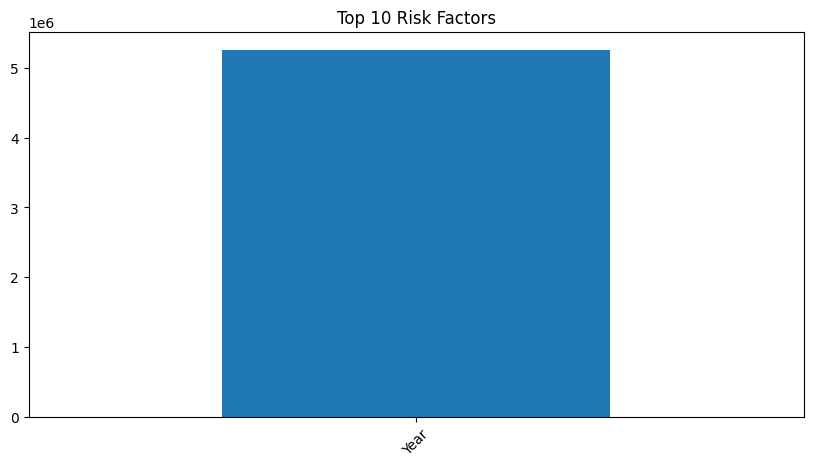

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

top_features = numeric_df.sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_features.plot(kind='bar')
plt.title("Top 10 Risk Factors")
plt.xticks(rotation=45)
plt.show()


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.shape)
print(numeric_df.head())
print(df.columns)
for col in df.columns:
    if 'Count' in col or 'Rate' in col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_df = df.select_dtypes(include=[np.number])

print(numeric_df.shape)
print(numeric_df.head())

(2604, 1)
   Year
0  2015
1  2015
2  2015
3  2015
4  2015
Index(['Year', 'Place', 'Age Group', 'Race and Ethnicity',
       'Count of Alcohol Consumption', 'Rate of Alcohol Consumption',
       'Count of Diabetes', 'Rate of Diabetes', 'Count of Hypertension',
       'Rate of Hypertension', 'Count of Smoking', 'Rate of Smoking',
       'Count of Low Weight Gain', 'Rate of Low Weight Gain',
       'Count of Inadequate Prenatal Care', 'Rate of Inadequate Prenatal Care',
       'Count of Other Risks', 'Rate of Other Risks'],
      dtype='object')
(2604, 15)
   Year  Count of Alcohol Consumption  Rate of Alcohol Consumption  \
0  2015                            31                          0.3   
1  2015                            28                          0.4   
2  2015                            51                          0.4   
3  2015                           112                          0.4   
4  2015                            33                          0.5   

   Count of Diabete

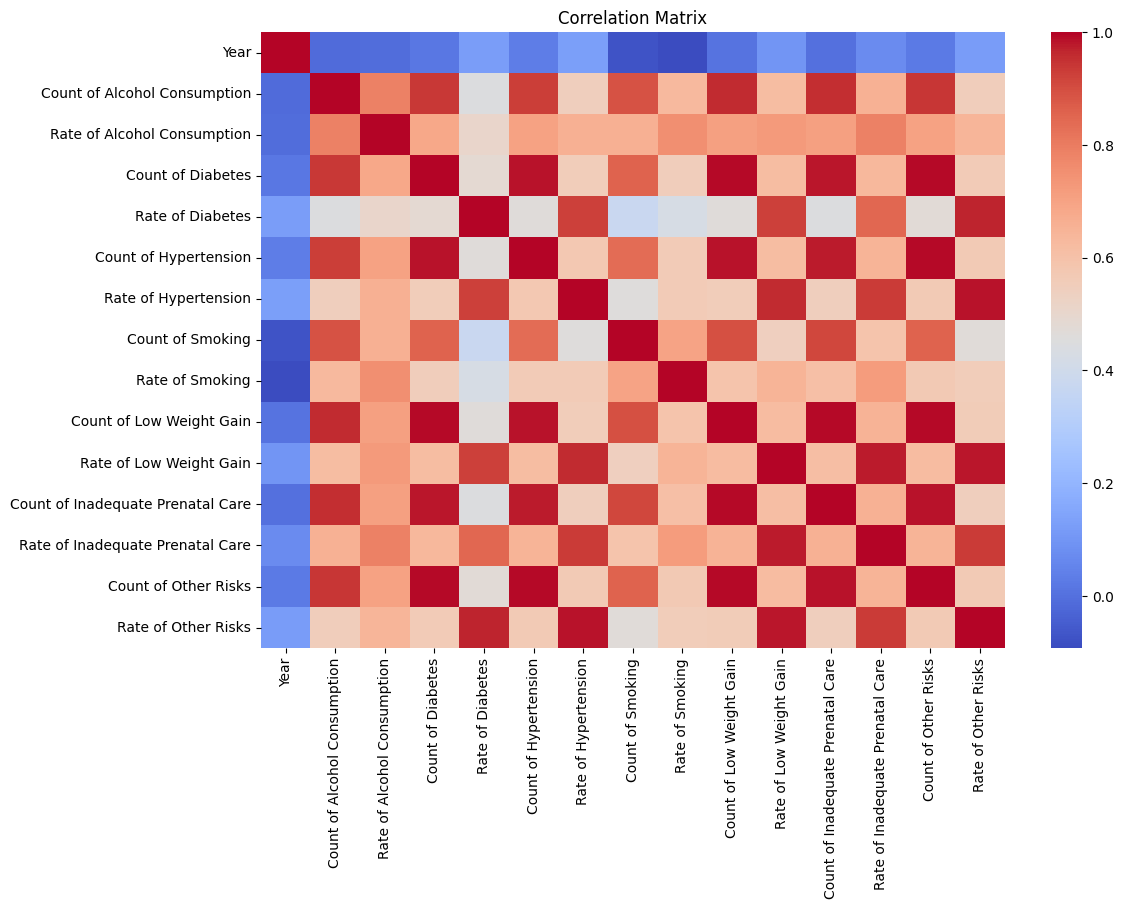

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

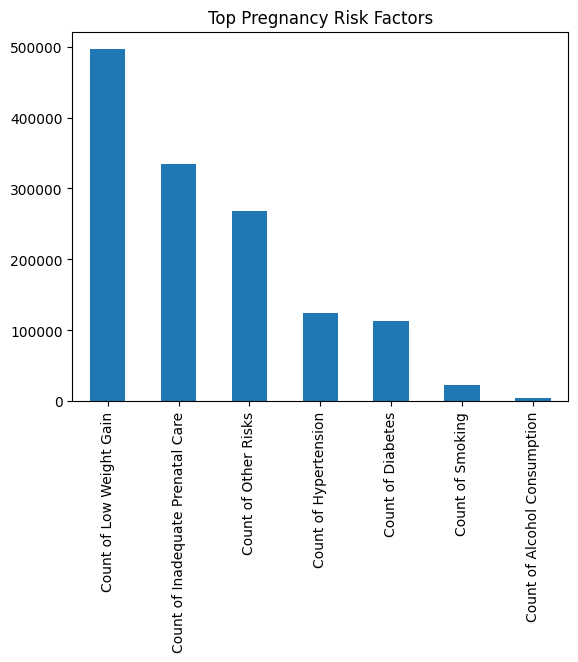

In [ ]:
df.filter(like='Count').sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Top Pregnancy Risk Factors")
plt.show()

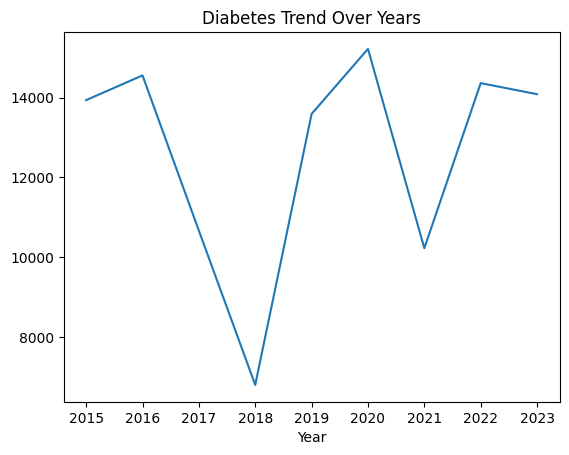

In [ ]:
df.groupby('Year')['Count of Diabetes'].sum().plot()
plt.title("Diabetes Trend Over Years")
plt.show()

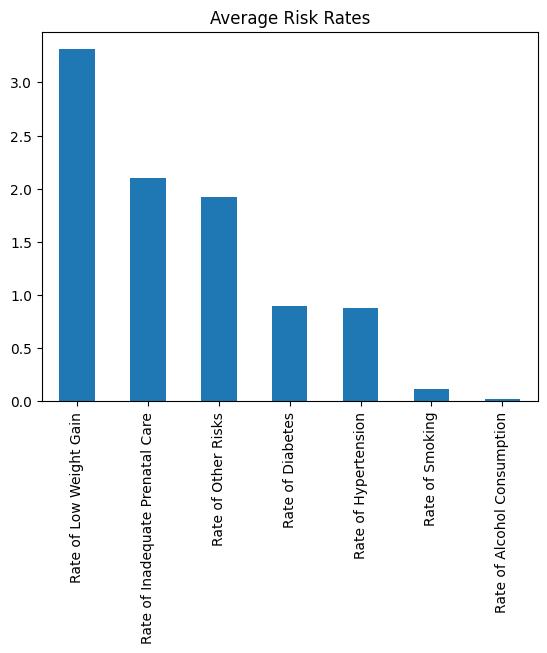

In [ ]:
df.filter(like='Rate').mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Risk Rates")
plt.show()